# 06 — Full Benchmark from XML

For large-scale experiments you can define the entire setup in an XML file
and let the Experiment class handle everything.

## The XML configuration

The file `benchmark_config.xml` defines:
- 2 datasets (Ricci, German)
- 12 methods (all available in scikit-fair)
- 2 classifiers (LogReg, XGBoost)
- 5-fold CV
- Both bias and fairness audits enabled

In [1]:
with open("benchmark_config.xml") as f:
    print(f.read())

<experiment>
  <datasets>
    <dataset name="ricci" />
    <dataset name="german" />
  </datasets>
  <methods>
    <method name="Baseline" />
    <method name="FairSmote" />
    <method name="Massaging" />
    <method name="FairOversampling" />
    <method name="FAWOS" />
    <method name="HeterogeneousFOS" />
    <method name="FairwayRemover" />
    <method name="GeometricFairnessRepair" />
    <method name="LearningFairRepresentations" />
    <method name="ReweighingClassifier" />
    <method name="FairBalanceClassifier" />
    <method name="FairMask" />
  </methods>
  <classifiers>
    <classifier path="sklearn.linear_model.LogisticRegression" name="LogReg" solver="liblinear" max_iter="1000" random_state="42" />
    <classifier path="xgboost.XGBClassifier" name="XGBoost" eval_metric="logloss" random_state="42" />
  </classifiers>
  <cv n_splits="5" random_state="42" />
  <audit bias="true" fairness="true" />
</experiment>



## Load, run, and auto-save

After loading from XML, we enable auto-save so results are persisted
automatically when `run()` completes.

In [2]:
import os
from skfair.experimentation import Experiment

os.makedirs("outputs", exist_ok=True)

exp = Experiment.from_xml("benchmark_config.xml")

# Enable auto-save (XML defaults these to False)
exp.save_results = True
exp.save_object = True
exp.save_path = "outputs/benchmark"

results = exp.run(verbose=True)
results


Dataset: Ricci
  Baseline                       | LogReg  acc=0.812  spd=-0.509
  Baseline                       | XGBoost  acc=0.940  spd=-0.316
  FairSmote                      | LogReg  acc=0.830  spd=-0.125
  FairSmote                      | XGBoost  acc=0.889  spd=-0.288
  Massaging                      | LogReg  acc=0.685  spd=0.004
  Massaging                      | XGBoost  acc=0.813  spd=-0.011
  FairOversampling               | LogReg  acc=0.787  spd=-0.162
  FairOversampling               | XGBoost  acc=0.940  spd=-0.316
  FAWOS                          | LogReg  acc=0.771  spd=-0.144
  FAWOS                          | XGBoost  acc=0.932  spd=-0.338
  HeterogeneousFOS               | LogReg  acc=0.864  spd=-0.128
  HeterogeneousFOS               | XGBoost  acc=0.940  spd=-0.355
  FairwayRemover                 | LogReg  acc=0.525  spd=-0.045
  FairwayRemover                 | XGBoost  acc=0.678  spd=-0.248
  GeometricFairnessRepair        | LogReg  acc=0.787  spd=-0.590
  G

/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib

  FairMask                       | LogReg  acc=0.862  spd=-0.403


/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib

  FairMask                       | XGBoost  acc=0.940  spd=-0.316

Dataset: German
  Baseline                       | LogReg  acc=0.752  spd=-0.102
  Baseline                       | XGBoost  acc=0.733  spd=-0.048
  FairSmote                      | LogReg  acc=0.707  spd=-0.024
  FairSmote                      | XGBoost  acc=0.715  spd=-0.013
  Massaging                      | LogReg  acc=0.734  spd=0.014
  Massaging                      | XGBoost  acc=0.756  spd=0.001
  FairOversampling               | LogReg  acc=0.721  spd=-0.029
  FairOversampling               | XGBoost  acc=0.731  spd=-0.052
  FAWOS                          | LogReg  acc=0.747  spd=-0.013
  FAWOS                          | XGBoost  acc=0.739  spd=-0.053
  HeterogeneousFOS               | LogReg  acc=0.676  spd=-0.026
  HeterogeneousFOS               | XGBoost  acc=0.716  spd=0.023
  FairwayRemover                 | LogReg  acc=0.743  spd=-0.003
  FairwayRemover                 | XGBoost  acc=0.739  spd=0.008
  Ge

/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib

  FairMask                       | LogReg  acc=0.739  spd=-0.025


/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/joao/anaconda3/envs/tese/lib

  FairMask                       | XGBoost  acc=0.735  spd=-0.009


,dataset,method,classifier,accuracy,balanced_accuracy,disparate_impact,spd,eod,aod
0,Ricci,Baseline,LogReg,0.811594,0.811655,0.289444,-0.509213,-0.334524,-0.323810
1,Ricci,Baseline,XGBoost,0.940217,0.940035,0.509113,-0.315754,0.078571,-0.039048
2,Ricci,FairSmote,LogReg,0.829710,0.834907,0.884608,-0.125369,0.102143,0.076151
3,Ricci,FairSmote,XGBoost,0.889130,0.888520,0.532662,-0.288298,-0.059524,-0.072024
4,Ricci,Massaging,LogReg,0.685145,0.687587,1.031284,0.003627,0.082381,0.132540
5,Ricci,Massaging,XGBoost,0.812681,0.812413,1.000909,-0.011373,0.275714,0.209206
6,Ricci,FairOversampling,LogReg,0.787319,0.795047,0.830303,-0.161884,0.015476,0.010595
7,Ricci,FairOversampling,XGBoost,0.940217,0.940035,0.509113,-0.315754,0.078571,-0.039048
8,Ricci,FAWOS,LogReg,0.770652,0.781177,0.830707,-0.143790,0.053571,0.032976
9,Ricci,FAWOS,XGBoost,0.931522,0.931061,0.477835,-0.337976,-0.021429,-0.089048


In [3]:
report = exp.to_report()
tables = report.summary_tables()
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df)

--- German ---


,accuracy,balanced_accuracy,disparate_impact,spd,eod,aod
method,,,,,,
Baseline,0.7425,0.6613,0.9070,-0.0749,-0.0376,-0.0588
FAWOS,0.7430,0.6536,0.9594,-0.0327,-0.0027,-0.0125
FairBalanceClassifier,0.7255,0.6920,0.9485,-0.0363,0.0033,-0.0147
FairMask,0.7370,0.6531,0.9794,-0.0168,0.0102,0.0040
FairOversampling,0.7260,0.6990,0.9398,-0.0407,-0.0114,-0.0096
FairSmote,0.7110,0.6869,0.9720,-0.0186,0.0141,0.0049
FairwayRemover,0.7410,0.6588,1.0050,0.0023,0.0283,0.0251
GeometricFairnessRepair,0.7485,0.6670,0.8883,-0.0910,-0.0500,-0.0758
HeterogeneousFOS,0.6960,0.6714,0.9950,-0.0014,0.0530,0.0087


--- Ricci ---


,accuracy,balanced_accuracy,disparate_impact,spd,eod,aod
method,,,,,,
Baseline,0.8759,0.8758,0.3993,-0.4125,-0.1280,-0.1814
FAWOS,0.8511,0.8561,0.6543,-0.2409,0.0161,-0.0280
FairBalanceClassifier,0.9020,0.9042,0.6422,-0.2470,0.0279,-0.0048
FairMask,0.9013,0.9017,0.4692,-0.3592,-0.0113,-0.1106
FairOversampling,0.8638,0.8675,0.6697,-0.2388,0.0470,-0.0142
FairSmote,0.8594,0.8617,0.7086,-0.2068,0.0213,0.0021
FairwayRemover,0.6018,0.5910,0.5502,-0.1462,-0.0604,-0.0994
GeometricFairnessRepair,0.8130,0.8141,0.3548,-0.4619,-0.2830,-0.2933
HeterogeneousFOS,0.9020,0.9045,0.6598,-0.2411,0.0179,0.0002


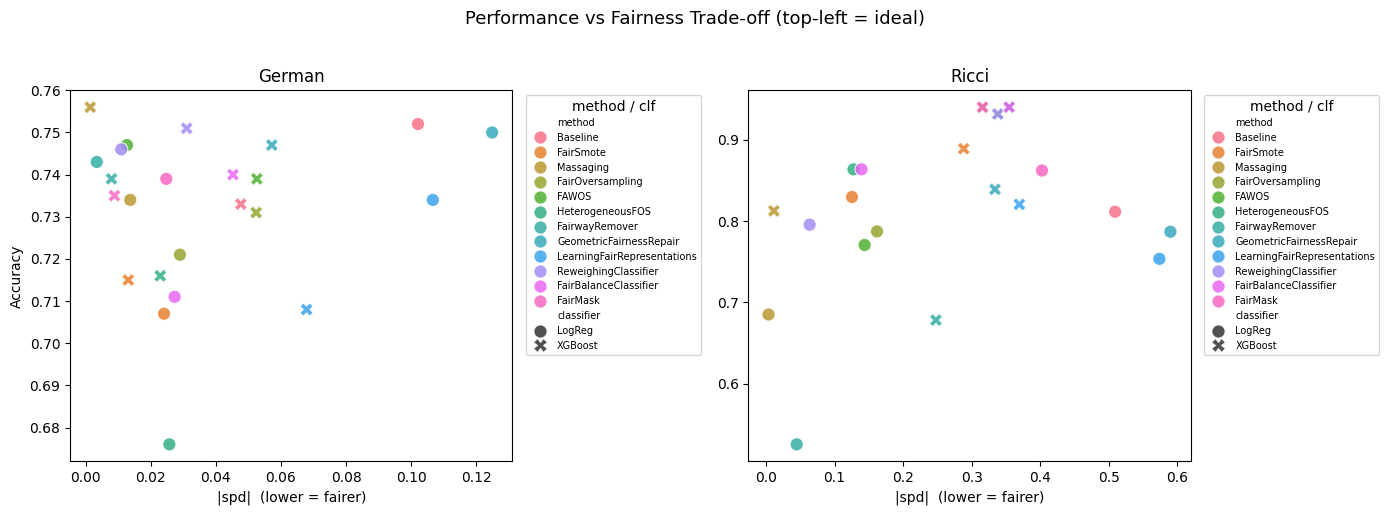

In [4]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");

## Reload a saved benchmark

Since we enabled `save_object`, the full experiment was pickled. We can
restore it later without re-running.

Datasets: [{'name': 'ricci', 'source': 'registry', 'key': 'ricci', 'data': None, 'sens_attr': None, 'priv_group': None}, {'name': 'german', 'source': 'registry', 'key': 'german', 'data': None, 'sens_attr': None, 'priv_group': None}]
Results shape: (48, 9)


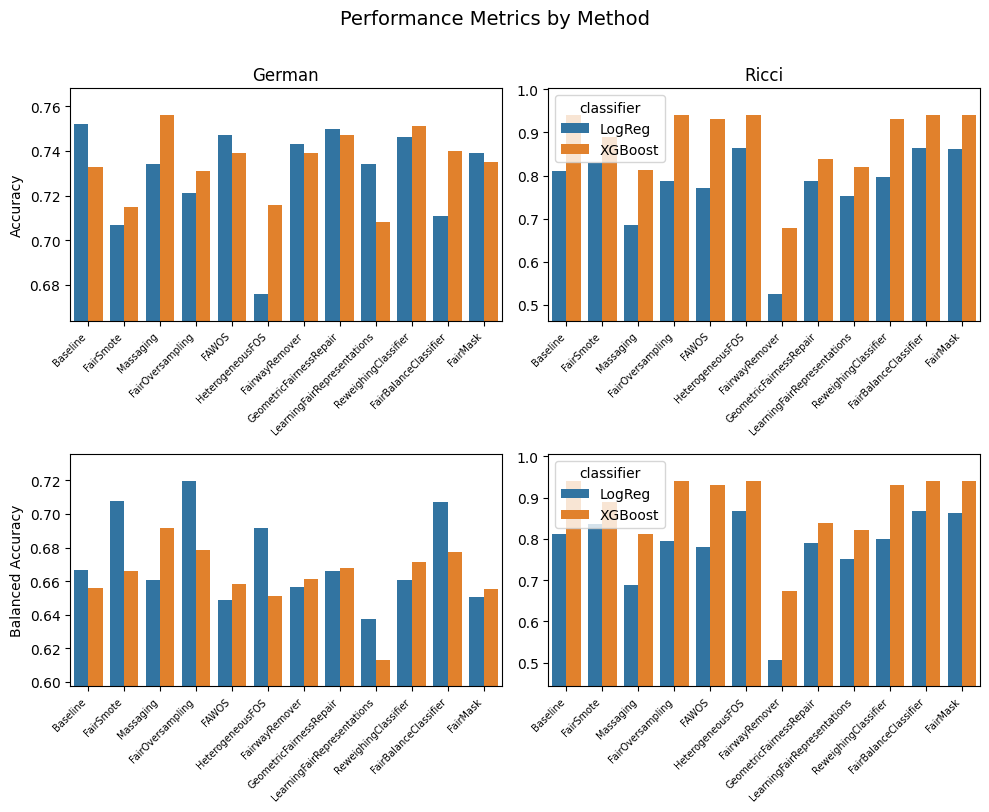

In [5]:
exp_loaded = Experiment.load("outputs/benchmark.pkl")
print("Datasets:", exp_loaded.datasets)
print("Results shape:", exp_loaded.results_.shape)
exp_loaded.to_report().plot_performance();